<a href="https://colab.research.google.com/github/raven-in-space/data-science-cohort-20/blob/main/Project-6/Image_Classification_with_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



* **Date:** `6/12/2026`
* **Author:** `Raven Otero-Symphony`
* **Program:** `CNM Ingenuity: Data Science Bootcamp`

## Problem Statement

Deep learning works at the intersection of data science, artificial intelligence, and machine learning. This project builds a **Convolutional Neural Network (CNN)** to predict whether an image is a 🐶 dog or a 🐱 cat, using a large dataset from Amazon AWS S3. This classic problem was a breakthrough in deep learning only 15 years ago.

**🤖 DISCLAIMER:** This was my first deep learning model for image classification as part of [CNM Ingenuity's Data Science Bootcamp](https://deepdivecoding.com/data-science/$0). To present the MVP of this project on-time, Ecosia AI was used to develop code and is denoted with the (🤖) emoji. The (🚩) emoji denotes refactoring these code cells at a later (TBD) date.

In [ ]:
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing import image
from keras.models import Sequential
from keras.utils import plot_model
import plotly.graph_objects as go
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from sklearn import datasets
from io import BytesIO
import tensorflow as tf
from PIL import Image
import pandas as pd
import numpy as np
import requests
import pickle
import os

## Data Cleaning

In [ ]:
# read in variables
image_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

print(f'y URL: {target_url}')
print(f'X URL: {image_url}')

y URL: https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle
X URL: https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle


In [ ]:
# unpickle
target = pd.read_pickle( target_url )
image_array = pd.read_pickle( image_url )

print(f'Type of y: {type(target_url)}')
print(f'Type of X: {type(image_array)}')

Type of y: <class 'str'>
Type of X: <class 'numpy.ndarray'>


In [ ]:
# divide by 255 to scale
image_array = (image_array / 255.0)
target = np.array(target)

print(f'X array: {image_array}')
print(f'Y: {target}')

X array: [[[[0.37254902]
   [0.36862745]
   [0.38431373]
   ...
   [0.66666667]
   [0.6745098 ]
   [0.67058824]]

  [[0.36078431]
   [0.35686275]
   [0.37254902]
   ...
   [0.66666667]
   [0.6745098 ]
   [0.67058824]]

  [[0.34901961]
   [0.35686275]
   [0.36078431]
   ...
   [0.64705882]
   [0.6627451 ]
   [0.6627451 ]]

  ...

  [[0.32941176]
   [0.29803922]
   [0.28627451]
   ...
   [0.52941176]
   [0.64313725]
   [0.60392157]]

  [[0.32156863]
   [0.30980392]
   [0.27843137]
   ...
   [0.55686275]
   [0.5254902 ]
   [0.6       ]]

  [[0.31372549]
   [0.33333333]
   [0.33333333]
   ...
   [0.59215686]
   [0.57254902]
   [0.54117647]]]


 [[[0.67058824]
   [0.60392157]
   [0.54509804]
   ...
   [0.7254902 ]
   [0.73333333]
   [0.7372549 ]]

  [[0.57254902]
   [0.54901961]
   [0.50588235]
   ...
   [0.73333333]
   [0.73333333]
   [0.7372549 ]]

  [[0.50196078]
   [0.51764706]
   [0.50196078]
   ...
   [0.72941176]
   [0.73333333]
   [0.7372549 ]]

  ...

  [[0.65490196]
   [0.65882353

## Exploratory Data Analysis

In [ ]:
print(f'Shape of X: {image_array.shape}')
print(f'Shape of y: {target.shape}')

Shape of X: (24946, 100, 100, 1)
Shape of y: (24946,)


* The `shape` matches and `X` is correctly in 4 dimensions!

0


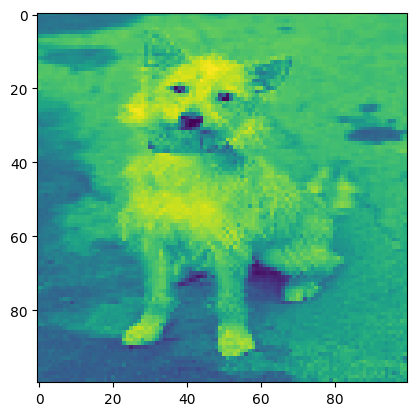

1


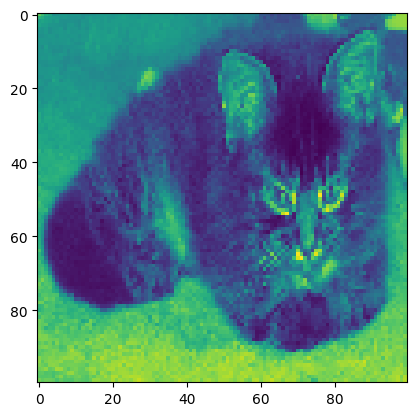

1


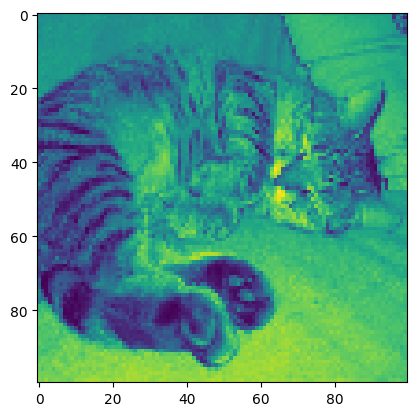

0


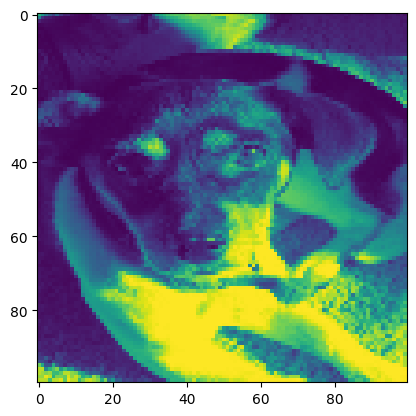

0


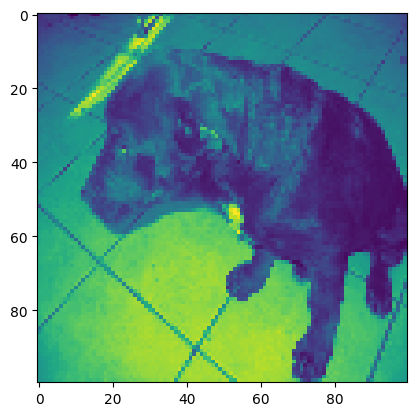

0


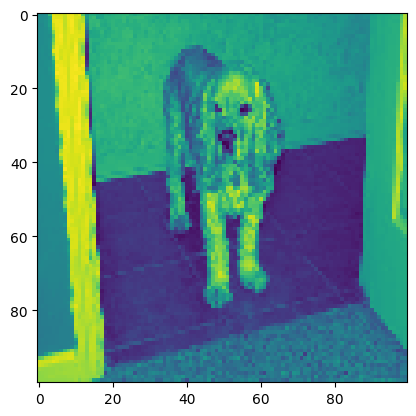

0


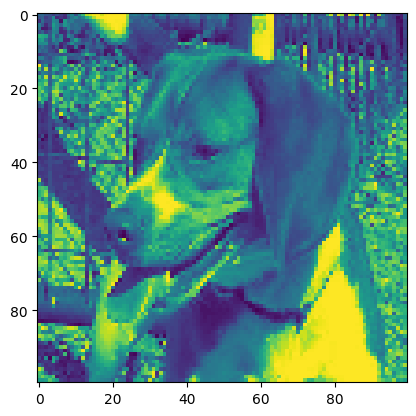

0


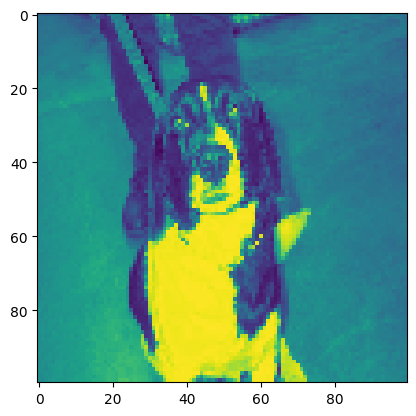

0


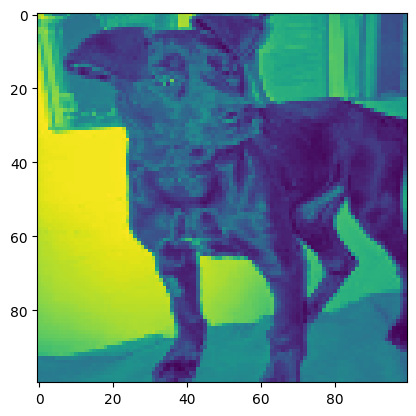

0


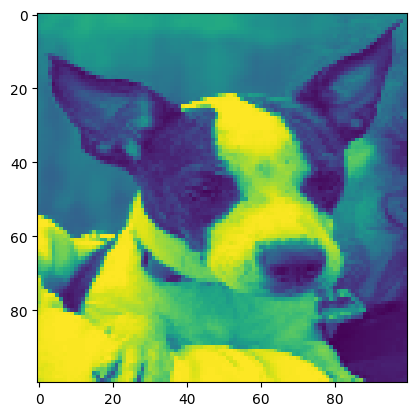

In [ ]:
for i in range(10):
  print(target[i])
  plt.imshow(image_array[i])
  plt.show()

## Data Processing

In [ ]:
# train/test
X_train, X_test, y_train, y_test = train_test_split( image_array, target, test_size = 0.2, random_state = 42 )

In [ ]:
# normalize
## X_train = tf.keras.utils.normalize(X_train, axis=1)
## X_test = tf.keras.utils.normalize(X_test, axis=1)

In [ ]:
# model selection
# model = Sequential()

# Flatten input data into a 1D structure
# model.add(Flatten())

# Define first hidden layers
# model.add(
#   Dense(
#     name = "hidden1",
#     units = 144,
#     activation = 'relu' ,
#   )
# )

# Add second hidden layer
# model.add(
#   Dense(
#     name = "hidden2",
#     units = 144,
#     activation = 'relu' ,
#   )
# )

# Define output layer
# model.add(
#   Dense(
#     name = "output",
#     units = 10,
#     activation = 'softmax' ,
#   )
# )

In [ ]:
# model selection
model = Sequential()

# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)

# Define first hidden layer
model.add(
  Conv2D(
    name = "Conv1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
    padding='same'
  )
)
model.add(MaxPooling2D(pool_size=(2,2)))

# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
    padding='same'
  )
)
model.add(MaxPooling2D(pool_size=(2,2)))

# Define third hidden layer
model.add(
  Conv2D(
    name = "Conv3",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
    padding='same'
  )
)
model.add(MaxPooling2D(pool_size=(2,2)))

In [ ]:
# Flatten data to be used in output layer
model.add(Flatten())

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 20, # 10
    activation = 'sigmoid',
  )
)

In [ ]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'sparse_categorical_crossentropy',
  metrics = ['accuracy'],
)

In [ ]:
# Fit model
model.fit(X_train, y_train, epochs=8, validation_data = (X_test, y_test))

Epoch 1/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.6317 - loss: 0.6426 - val_accuracy: 0.7405 - val_loss: 0.5294
Epoch 2/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7465 - loss: 0.5146 - val_accuracy: 0.7902 - val_loss: 0.4636
Epoch 3/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7984 - loss: 0.4407 - val_accuracy: 0.8062 - val_loss: 0.4149
Epoch 4/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8248 - loss: 0.3870 - val_accuracy: 0.8329 - val_loss: 0.3728
Epoch 5/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8483 - loss: 0.3462 - val_accuracy: 0.8329 - val_loss: 0.3754
Epoch 6/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8688 - loss: 0.3004 - val_accuracy: 0.8407 - val_loss: 0.3764
Epoch 7/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8881 - loss: 0.2595 - val_accuracy: 0.8449 - val_loss: 0.3593
Epoch 8/8
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9084 - loss: 0.2192 - val_accu

## Communication of Results

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 100, 100, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 20)             │       184,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 776,510 (2.96 MB)

 Trainable params: 258,836 (1011.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 517,674 (1.97 MB)

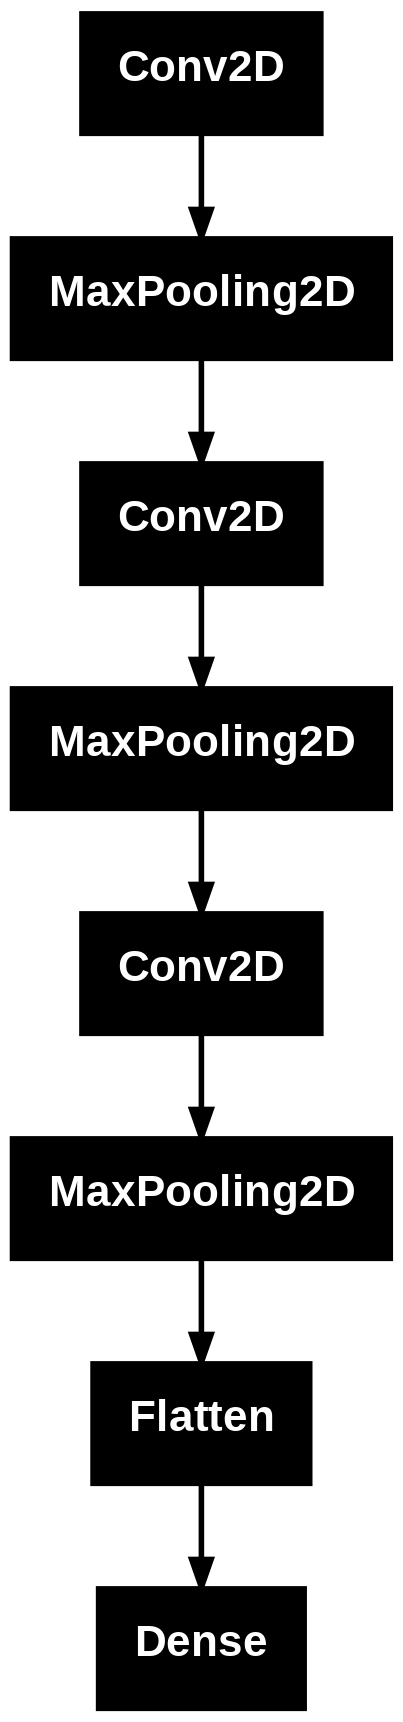

In [ ]:
plot_model(model)

In [ ]:
# evaluate accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8525 - loss: 0.3557
Test Accuracy: 0.8525050282478333


*🚩 Refactor Code*

In [ ]:
## 🤖 DISCLAIMER: AI Usage (Ecosia AI)

# Get predicted probabilities for the test set
probabilities = model.predict(X_test)

# Create a figure
fig = go.Figure()

# Add a histogram for all classes
fig.add_trace(
    go.Histogram(
        x=probabilities.flatten(),
        name="All Classes",
        opacity=0.7,
        nbinsx=50,
        marker_color="gold"
    )
)

# Update layout with custom background colors
fig.update_layout(
    title="Aggregate Distribution of Predicted Probabilities",
    xaxis_title="Predicted Probability",
    yaxis_title="Frequency",
    width=800,
    height=500,
    plot_bgcolor="rgb(39, 42, 44)",  # Dark gray background for plot area
    paper_bgcolor="rgb(39, 42, 44)",  # Dark gray background for the entire figure
    font=dict(color="white")  # Optional: Set text color to white for better contrast
)

# Update x and y axes to match background
fig.update_xaxes(showgrid=False, gridcolor="rgb(39, 42, 44)")
fig.update_yaxes(showgrid=False, gridcolor="rgb(39, 42, 44)")

# Show the figure
fig.show()

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


*🚩 Refactor Code*

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step


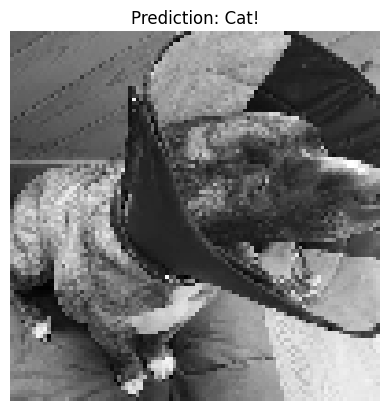

In [ ]:
## 🤖 DISCLAIMER: AI Usage (Ecosia AI)

def predict_dog_or_cat(url, target_size = (100, 100)):
  '''
  Converts an image to greyscale for use in deep learning predictor model.
  '''
  response = requests.get(url)
  img = image.load_img(BytesIO(response.content), color_mode = 'grayscale', target_size = target_size)
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis = 0)
  return (img_array / 255.0)

new_doggy_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
dog_or_cat = predict_dog_or_cat(new_doggy_url)
prediction = model.predict(dog_or_cat)

plt.imshow(dog_or_cat.squeeze(), cmap='gray')
plt.axis('off')
plt.title(f"Prediction: {'Dog!' if prediction.argmax() == 1 else 'Cat!'}")
plt.show()

## BONUS

The `folder_path` has been removed for privacy and security reasons.

This section applied the model on real world pictures of my dogs.

Of the 6 images, only 2 were correctly predicted as "dog." See the slides for more information.

In [ ]:
# Anchor drive
from google.colab import drive
drive.mount('/content/drive')

*🚩 Refactor Code*

In [ ]:
## 🤖 DISCLAIMER: AI Usage (Ecosia AI)

def predict_dog_or_cat(img_path, target_size=(100, 100)):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    img = img.resize(target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img_array

# Folder containing images
folder_path = "INSERT_PATH"

# Get all image files in the folder
image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Predict and display each image
plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files, 1):
    img_path = os.path.join(folder_path, img_file)
    processed_image = predict_dog_or_cat(img_path)
    prediction = model.predict(processed_image)
    result = "Dog" if prediction.argmax() == 1 else "Cat"

    # Display the image and prediction
    plt.subplot(4, 5, i)
    plt.imshow(processed_image.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"{img_file}\n{result}", fontsize=10)

plt.tight_layout()
plt.show()